In [126]:
#pip install pandas


In [127]:
#pip install seaborn

In [128]:
#%pip install matplotlib xgboost scikit-learn imbalanced-learn

In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/1999 czech banking/fraud_detection/utku_project/final_loan_data.csv")

In [131]:
main_df

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,B,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,A,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,D,POPLATEK MESICNE,45,45,520826,20,130,948153.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7295,11328,280440,60,4674.0,C,POPLATEK MESICNE,13616,13924,525909,54,146,1326820.0
823,7304,11349,419880,60,6998.0,C,POPLATEK TYDNE,13647,13955,456030,1,304,3957372.2
824,7304,11349,419880,60,6998.0,C,POPLATEK TYDNE,13648,13956,430406,1,304,3957372.2
825,7305,11359,54024,12,4502.0,A,POPLATEK MESICNE,13660,13968,680413,61,378,2948081.4


In [132]:
main_df.isna().sum()

loan_id               0
account_id            0
amount                0
duration              0
payments              0
status                0
frequency             0
disp_id               0
client_id             0
birth_number          0
district_id           0
total_trans           0
total_trans_amount    0
dtype: int64

In [133]:
main_df.head(10)

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,A,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,B,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,A,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,D,POPLATEK MESICNE,45,45,520826,20,130,948153.9
5,4968,38,110736,48,2307.0,C,POPLATEK TYDNE,46,46,405130,19,130,571949.7
6,4973,67,165960,24,6915.0,A,POPLATEK MESICNE,78,78,445613,16,382,4518164.0
7,4986,97,102876,12,8573.0,A,POPLATEK MESICNE,116,116,420128,74,274,1229256.4
8,4986,97,102876,12,8573.0,A,POPLATEK MESICNE,117,117,365920,74,274,1229256.4
9,4988,103,265320,36,7370.0,D,POPLATEK MESICNE,124,124,670921,44,185,1714751.3


<Axes: xlabel='amount', ylabel='total_trans_amount'>

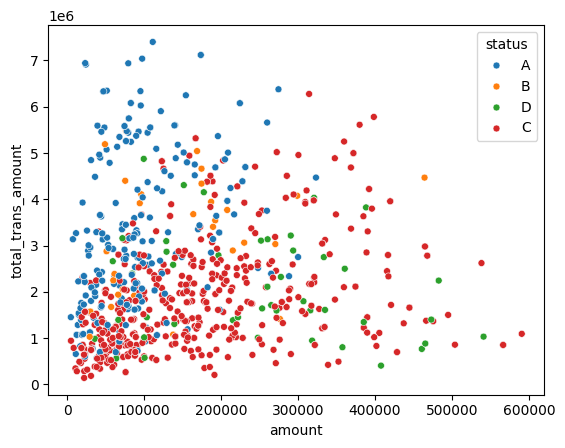

In [134]:
sns.scatterplot(data=main_df,x="amount",y="total_trans_amount",s=25,hue="status")

In [135]:
main_df['status'].value_counts()

status
C    493
A    258
D     45
B     31
Name: count, dtype: int64

In [136]:
main_df['status'] = main_df['status'].map({"A": 1, "B": 0, "C": 2, "D": 3})

In [137]:
main_df['status']

0      1
1      1
2      0
3      1
4      3
      ..
822    2
823    2
824    2
825    1
826    1
Name: status, Length: 827, dtype: int64

In [138]:
copy_df = main_df[["amount","total_trans_amount","status"]].copy()

In [139]:
copy_df

,amount,total_trans_amount,status
0,80952,3151479.3,1
1,80952,3151479.3,1
2,30276,1575515.9,0
3,30276,2958545.1,1
4,318480,948153.9,3
...,...,...,...
822,280440,1326820.0,2
823,419880,3957372.2,2
824,419880,3957372.2,2
825,54024,2948081.4,1


In [140]:
from sklearn.cluster import KMeans

In [141]:
cluster_k = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i,random_state=46)
    kmeans.fit(copy_df)
    cluster_k.append(kmeans.inertia_)
# inertia bir ozellik her noktanin,ait oldugu kumenin merkezine olan uzakliklarinin karelerinin toplami olarak tanimlanabilir. Kume sayisi arttikca inertia degerinin azalmasi beklenir. Ancak, belirli bir noktadan sonra inertia degeri cok az azalir ve bu noktada optimal kume sayisi olarak kabul edilir. Bu noktayi bulmak icin, cluster_k degerlerini kullanarak bir grafik cizilebilir ve "dirsek noktasi" olarak adlandirilan noktayi belirlemek icin incelenebilir.

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extm

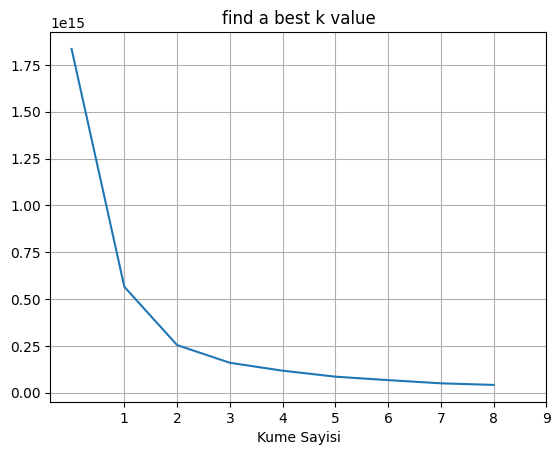

In [142]:
sns.lineplot(data=cluster_k)
plt.xticks(range(1,10))
plt.xlabel("Kume Sayisi")
plt.title("find a best k value")
plt.grid()

In [143]:
#k=4

In [144]:
cluster_model = KMeans(n_clusters=4)
cluster_model.fit(copy_df)
copy_df["cluster"] = cluster_model.predict(copy_df)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: xlabel='amount', ylabel='total_trans_amount'>

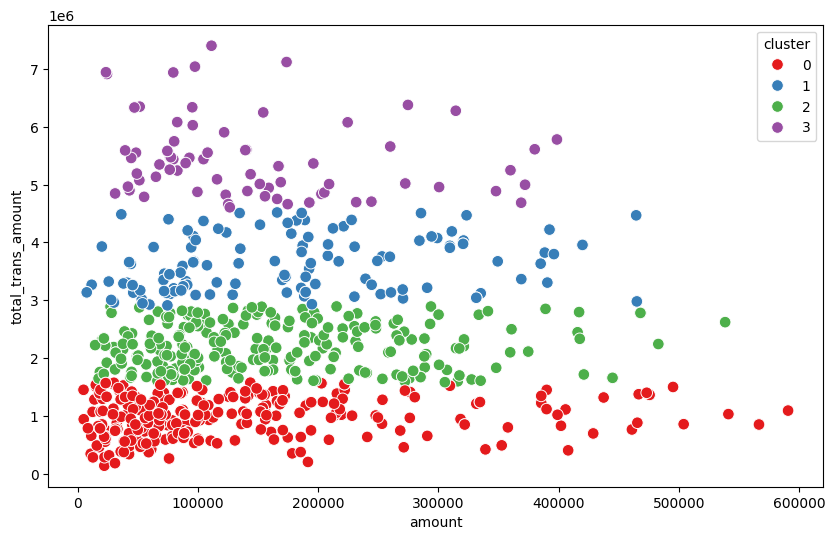

In [145]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=copy_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")

In [146]:
main_df

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,4959,2,80952,24,3373.0,1,POPLATEK MESICNE,2,2,450204,1,478,3151479.3
1,4959,2,80952,24,3373.0,1,POPLATEK MESICNE,3,3,406009,1,478,3151479.3
2,4961,19,30276,12,2523.0,0,POPLATEK MESICNE,25,25,395423,21,303,1575515.9
3,4962,25,30276,12,2523.0,1,POPLATEK MESICNE,31,31,620209,68,274,2958545.1
4,4967,37,318480,60,5308.0,3,POPLATEK MESICNE,45,45,520826,20,130,948153.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7295,11328,280440,60,4674.0,2,POPLATEK MESICNE,13616,13924,525909,54,146,1326820.0
823,7304,11349,419880,60,6998.0,2,POPLATEK TYDNE,13647,13955,456030,1,304,3957372.2
824,7304,11349,419880,60,6998.0,2,POPLATEK TYDNE,13648,13956,430406,1,304,3957372.2
825,7305,11359,54024,12,4502.0,1,POPLATEK MESICNE,13660,13968,680413,61,378,2948081.4


In [147]:
main_df['frequency'].value_counts()

frequency
POPLATEK MESICNE      680
POPLATEK TYDNE        107
POPLATEK PO OBRATU     40
Name: count, dtype: int64

In [148]:
main_df.isna().sum()

loan_id               0
account_id            0
amount                0
duration              0
payments              0
status                0
frequency             0
disp_id               0
client_id             0
birth_number          0
district_id           0
total_trans           0
total_trans_amount    0
dtype: int64

In [149]:
main_df.describe()

,loan_id,account_id,amount,duration,payments,status,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,8.270000e+02
mean,6180.746070,5863.874244,151801.538089,36.261185,4231.251511,1.667473,7049.634825,7171.419589,582148.870617,38.215236,282.499395,2.327635e+06
std,681.292733,3277.925506,114577.041848,17.172800,2238.757849,0.637370,3925.311133,4053.288033,129709.966792,25.033481,136.893018,1.486102e+06
min,4959.000000,2.000000,4980.000000,12.000000,304.000000,0.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05
25%,5585.000000,2988.000000,67536.000000,24.000000,2495.500000,1.000000,3608.500000,3608.500000,470126.500000,14.000000,175.000000,1.135261e+06
50%,6190.000000,5794.000000,115992.000000,36.000000,3937.000000,2.000000,7011.000000,7011.000000,580821.000000,41.000000,253.000000,2.020074e+06
75%,6760.500000,8757.000000,210564.000000,48.000000,5916.000000,2.000000,10487.500000,10795.500000,688169.500000,60.000000,392.500000,3.137644e+06
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,13663.000000,13971.000000,851019.000000,77.000000,675.000000,7.399358e+06


In [150]:
main_df['frequency']=main_df['frequency'].map({"POPLATEK MESICNE":1, "POPLATEK TYDNE":2, "POPLATEK PO OBRATU":3,})

In [151]:
copy_df = main_df.copy()
unscaled_cluster = KMeans(n_clusters=4,random_state=46)
unscaled_cluster.fit(copy_df)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


KMeans(n_clusters=4, random_state=46)

In [152]:
copy_df['cluster'] = unscaled_cluster.predict(copy_df)

In [153]:
copy_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,4959,2,80952,24,3373.0,1,1,2,2,450204,1,478,3151479.3,1
1,4959,2,80952,24,3373.0,1,1,3,3,406009,1,478,3151479.3,1
2,4961,19,30276,12,2523.0,0,1,25,25,395423,21,303,1575515.9,0
3,4962,25,30276,12,2523.0,1,1,31,31,620209,68,274,2958545.1,1
4,4967,37,318480,60,5308.0,3,1,45,45,520826,20,130,948153.9,0


In [154]:
copy_df['cluster'].value_counts()

cluster
0    316
2    276
1    147
3     88
Name: count, dtype: int64

In [155]:
copy_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,4959,2,80952,24,3373.0,1,1,2,2,450204,1,478,3151479.3,1
1,4959,2,80952,24,3373.0,1,1,3,3,406009,1,478,3151479.3,1
2,4961,19,30276,12,2523.0,0,1,25,25,395423,21,303,1575515.9,0
3,4962,25,30276,12,2523.0,1,1,31,31,620209,68,274,2958545.1,1
4,4967,37,318480,60,5308.0,3,1,45,45,520826,20,130,948153.9,0


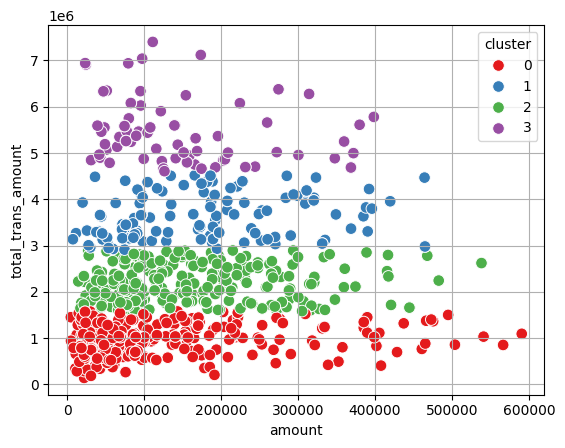

In [156]:
sns.scatterplot(data=copy_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")
plt.grid()

In [157]:
## rescale
#describe big std = outlier check
# describe = big max = log

In [158]:
copy_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,8.270000e+02,827.000000
mean,6180.746070,5863.874244,151801.538089,36.261185,4231.251511,1.667473,1.226119,7049.634825,7171.419589,582148.870617,38.215236,282.499395,2.327635e+06,1.164450
std,681.292733,3277.925506,114577.041848,17.172800,2238.757849,0.637370,0.521587,3925.311133,4053.288033,129709.966792,25.033481,136.893018,1.486102e+06,1.056305
min,4959.000000,2.000000,4980.000000,12.000000,304.000000,0.000000,1.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05,0.000000
25%,5585.000000,2988.000000,67536.000000,24.000000,2495.500000,1.000000,1.000000,3608.500000,3608.500000,470126.500000,14.000000,175.000000,1.135261e+06,0.000000
50%,6190.000000,5794.000000,115992.000000,36.000000,3937.000000,2.000000,1.000000,7011.000000,7011.000000,580821.000000,41.000000,253.000000,2.020074e+06,1.000000
75%,6760.500000,8757.000000,210564.000000,48.000000,5916.000000,2.000000,1.000000,10487.500000,10795.500000,688169.500000,60.000000,392.500000,3.137644e+06,2.000000
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,3.000000,13663.000000,13971.000000,851019.000000,77.000000,675.000000,7.399358e+06,3.000000


In [159]:
# mean and median
# min vs max
# std vs mean


In [160]:
## mean >. max = outlier
## amount duration paymnents disp client_id	 district_id total_trans_amount

In [161]:
copy_df[['amount','duration','payments','disp_id','client_id','district_id','total_trans_amount']]

,amount,duration,payments,disp_id,client_id,district_id,total_trans_amount
0,80952,24,3373.0,2,2,1,3151479.3
1,80952,24,3373.0,3,3,1,3151479.3
2,30276,12,2523.0,25,25,21,1575515.9
3,30276,12,2523.0,31,31,68,2958545.1
4,318480,60,5308.0,45,45,20,948153.9
...,...,...,...,...,...,...,...
822,280440,60,4674.0,13616,13924,54,1326820.0
823,419880,60,6998.0,13647,13955,1,3957372.2
824,419880,60,6998.0,13648,13956,1,3957372.2
825,54024,12,4502.0,13660,13968,61,2948081.4


In [162]:
copy_df["amount"] = np.log1p(copy_df["amount"])
copy_df["duration"] = np.log1p(copy_df["duration"])
copy_df["payments"] = np.log1p(copy_df["payments"])
copy_df["disp_id"] = np.log1p(copy_df["disp_id"])
copy_df["client_id"] = np.log1p(copy_df["client_id"])
copy_df["district_id"] = np.log1p(copy_df["district_id"])
copy_df["total_trans_amount"] = np.log1p(copy_df["total_trans_amount"])

In [163]:
copy_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
count,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000
mean,6180.746070,5863.874244,11.615338,3.484903,8.167761,1.667473,1.226119,8.560833,8.571776,582148.870617,3.235868,282.499395,14.443169,1.164450
std,681.292733,3277.925506,0.857255,0.549945,0.674331,0.637370,0.521587,1.027657,1.035552,129709.966792,1.175743,136.893018,0.693054,1.056305
min,4959.000000,2.000000,8.513386,2.564949,5.720312,0.000000,1.000000,1.098612,1.098612,341130.000000,0.693147,49.000000,11.862671,0.000000
25%,5585.000000,2988.000000,11.120430,3.218876,7.822643,1.000000,1.000000,8.191325,8.191325,470126.500000,2.708050,175.000000,13.942351,0.000000
50%,6190.000000,5794.000000,11.661285,3.610918,8.278428,2.000000,1.000000,8.855378,8.855378,580821.000000,3.737670,253.000000,14.518645,1.000000
75%,6760.500000,8757.000000,12.257549,3.891820,8.685585,2.000000,1.000000,9.258033,9.286976,688169.500000,4.110874,392.500000,14.958983,2.000000
max,7308.000000,11362.000000,13.289268,4.110874,9.201401,3.000000,3.000000,9.522520,9.544811,851019.000000,4.356709,675.000000,15.816904,3.000000


In [164]:
# log transformation is doing great job no more extreme outliers

In [165]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
copy_df1 = main_df.copy()
sc = StandardScaler()
scaled_df = sc.fit_transform(copy_df1)
scaled_df = pd.DataFrame(scaled_df, columns=copy_df1.columns)
scaled_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
0,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796520,-1.769861,-1.017846,-1.487518,1.428991,0.554701
1,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796265,-1.769615,-1.358773,-1.487518,1.428991,0.554701
2,-1.791424,-1.784181,-1.061287,-1.413623,-0.763497,-2.617759,-0.433782,-1.790657,-1.764184,-1.440436,-0.688105,0.149847,-0.506408
3,-1.789955,-1.782349,-1.061287,-1.413623,-0.763497,-1.047863,-0.433782,-1.789128,-1.762702,0.293602,1.190517,-0.062125,0.424797
4,-1.782612,-1.778686,1.455609,1.383186,0.481249,2.091929,-0.433782,-1.785559,-1.759246,-0.473055,-0.728075,-1.114678,-0.928817


In [166]:
# After scaling the data , we rechecked the number of clusters
cluster_k = []
for i in range(1,10):
    km = KMeans(n_clusters=i,random_state=46)
    km.fit(scaled_df)
    cluster_k.append(km.inertia_)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extm

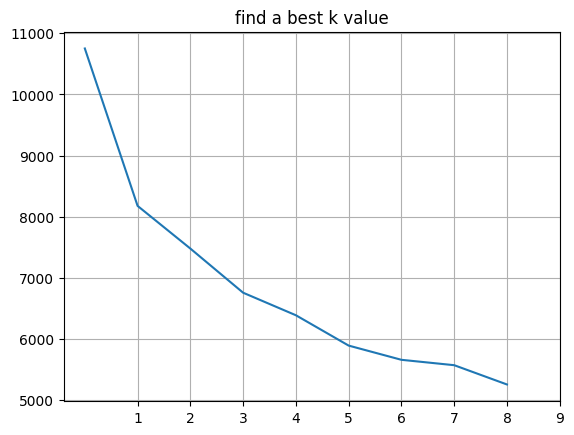

In [167]:
sns.lineplot(data=cluster_k)
plt.xticks(range(1,10))
plt.title("find a best k value")
plt.grid()

In [168]:
# k=5
scaled_cluster_model = KMeans(n_clusters=5,random_state=46)
scaled_cluster_model.fit(scaled_df)
scaled_df['cluster'] = scaled_cluster_model.predict(scaled_df)
scaled_df.head()

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,cluster
0,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796520,-1.769861,-1.017846,-1.487518,1.428991,0.554701,1
1,-1.794361,-1.789370,-0.618731,-0.714421,-0.383593,-1.047863,-0.433782,-1.796265,-1.769615,-1.358773,-1.487518,1.428991,0.554701,1
2,-1.791424,-1.784181,-1.061287,-1.413623,-0.763497,-2.617759,-0.433782,-1.790657,-1.764184,-1.440436,-0.688105,0.149847,-0.506408,1
3,-1.789955,-1.782349,-1.061287,-1.413623,-0.763497,-1.047863,-0.433782,-1.789128,-1.762702,0.293602,1.190517,-0.062125,0.424797,1
4,-1.782612,-1.778686,1.455609,1.383186,0.481249,2.091929,-0.433782,-1.785559,-1.759246,-0.473055,-0.728075,-1.114678,-0.928817,1


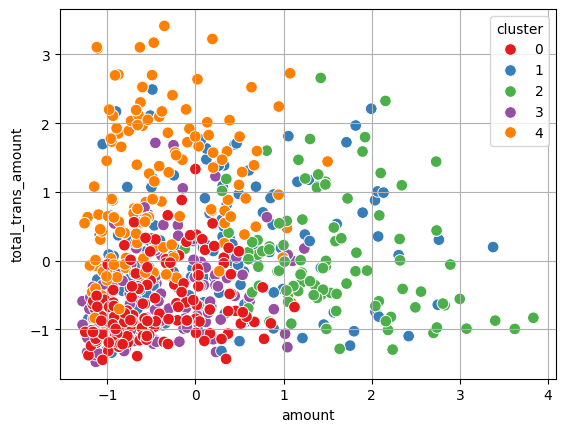

In [169]:
sns.scatterplot(data=scaled_df,x="amount",y="total_trans_amount",hue="cluster",s=70,palette="Set1")
plt.grid()

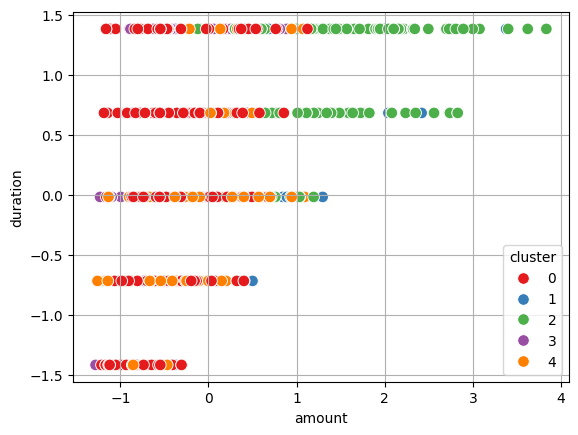

In [170]:
sns.scatterplot(data=scaled_df,x="amount",y="duration",hue="cluster",s=70,palette="Set1")
plt.grid()

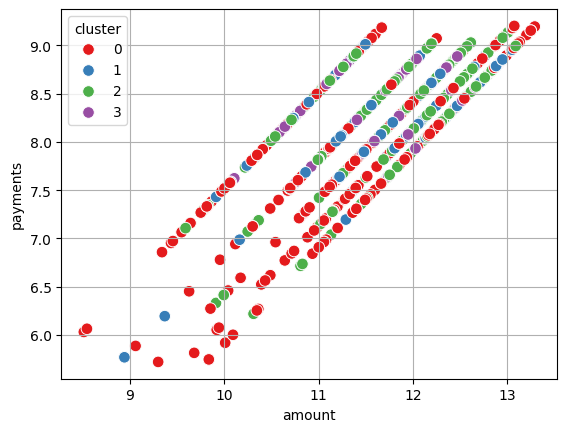

In [171]:
sns.scatterplot(data=copy_df,x="amount",y="payments",hue="cluster",s=70,palette="Set1")
plt.grid()

<Axes: xlabel='frequency', ylabel='payments'>

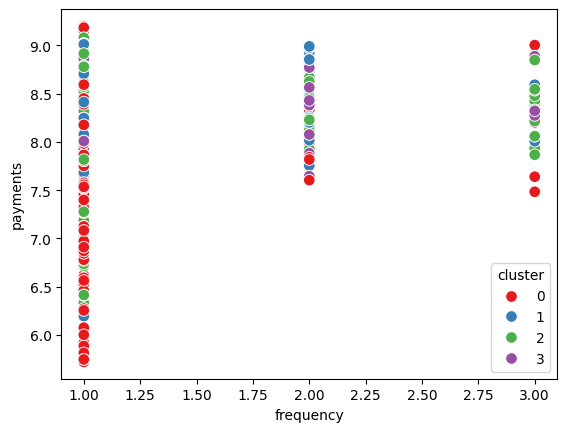

In [172]:
sns.scatterplot(data=copy_df,x="frequency",y="payments",hue="cluster",s=70,palette="Set1")

<Axes: xlabel='cluster', ylabel='amount'>

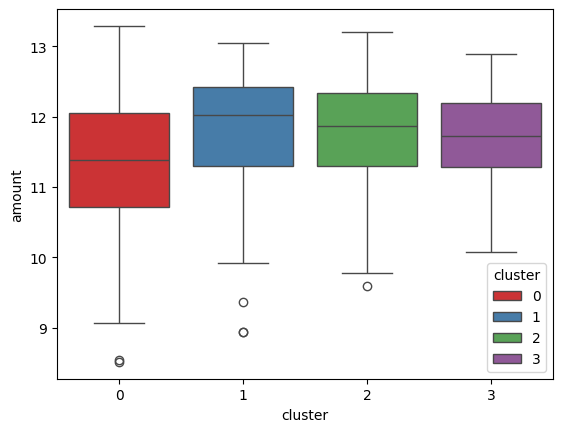

In [173]:
sns.boxplot(data=copy_df,x="cluster",y="amount",hue="cluster",palette="Set1")

In [174]:
scaled_df.groupby("cluster").mean()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
cluster,,,,,,,,,,,,,
0,0.994400,0.998072,-0.451730,-0.023119,-0.465058,0.309166,-0.303722,0.996728,1.000917,0.001322,-0.056026,-0.484542,-0.620776
1,-1.224262,-1.216710,0.191016,-0.190974,0.483848,-0.164260,0.331475,-1.218495,-1.210086,-0.451643,0.029839,-0.038080,0.112503
2,0.473173,0.468798,1.642973,1.049054,0.935960,0.744319,0.075523,0.469802,0.465949,0.257353,0.033136,-0.137548,0.067037
3,-0.608353,-0.613212,-0.408234,0.133792,-0.638740,0.453404,-0.213640,-0.610449,-0.621240,0.202743,0.002755,-0.494578,-0.551506
4,0.619248,0.615455,-0.385667,-0.608109,0.028639,-1.121308,0.138368,0.615137,0.615895,0.094935,0.001214,1.162476,1.068069


In [175]:
#i build a supervised regression algorithm  for median house value

In [176]:
from sklearn.model_selection import train_test_split

In [177]:
train_df,test_df = train_test_split(main_df,random_state=46)

In [178]:
train_df.head()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
188,5525,2720,93888,36,2608.0,2,2,3285,3285,435917,2,167,2073922.5
771,7168,10645,208332,36,5787.0,2,1,12782,13090,805418,2,163,2531327.1
578,6682,8225,36204,12,3017.0,3,1,9851,10159,380106,50,196,987028.5
132,5368,2073,44640,24,1860.0,2,1,2514,2514,570211,59,83,576532.9
438,6278,6265,87360,24,3640.0,2,1,7567,7567,370315,5,198,2235757.0


In [179]:
train_df.describe()

,loan_id,account_id,amount,duration,payments,status,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,6.200000e+02
mean,6182.629032,5873.314516,148215.832258,36.251613,4162.537097,1.675806,1.233871,7060.666129,7183.369355,579975.985484,38.317742,278.145161,2.303258e+06
std,675.338241,3249.193955,110938.883329,17.125629,2194.325932,0.640372,0.528797,3890.289678,4018.468535,132064.328191,25.025945,135.860561,1.482640e+06
min,4959.000000,2.000000,7656.000000,12.000000,304.000000,0.000000,1.000000,2.000000,2.000000,341130.000000,1.000000,49.000000,1.418696e+05
25%,5588.250000,3002.250000,67887.000000,24.000000,2480.750000,1.000000,1.000000,3625.750000,3625.750000,460553.250000,14.750000,173.000000,1.106022e+06
50%,6196.000000,5842.500000,110124.000000,36.000000,3874.000000,2.000000,1.000000,7069.000000,7069.000000,580713.000000,41.000000,249.000000,1.978975e+06
75%,6758.000000,8742.000000,204150.000000,48.000000,5667.750000,2.000000,1.000000,10469.250000,10777.250000,692006.250000,60.250000,386.250000,3.133090e+06
max,7308.000000,11362.000000,590820.000000,60.000000,9910.000000,3.000000,3.000000,13663.000000,13971.000000,845918.000000,77.000000,675.000000,7.399358e+06


In [180]:
# max / median  amount  payments, frequency,birth_number
# std / mean   account_id,amount,payment,status,disp_id,client_id,district  
# a log transformation is appropriate.

In [181]:
train_df["loan_intensity"] =train_df["amount"] / train_df["total_trans_amount"]
train_df["amount_per_duration"] = train_df["amount"] / train_df["duration"]
test_df["loan_intensity"] =test_df["amount"] / test_df["total_trans_amount"]
test_df["amount_per_duration"] = test_df["amount"] / test_df["duration"]

In [182]:
train_df['loan_intensity']= np.log1p(train_df['loan_intensity'])
train_df['amount_per_duration']= np.log1p(train_df['amount_per_duration'])
train_df['account_id']= np.log1p(train_df['account_id'])
train_df['amount']= np.log1p(train_df['amount'])
train_df['payments']= np.log1p(train_df['payments'])
train_df['disp_id']= np.log1p(train_df['disp_id'])
train_df['client_id']= np.log1p(train_df['client_id'])
train_df['district_id']= np.log1p(train_df['district_id'])


In [183]:
test_df['loan_intensity']= np.log1p(test_df['loan_intensity'])
test_df['amount_per_duration']= np.log1p(test_df['amount_per_duration'])
test_df['account_id']= np.log1p(test_df['account_id'])
test_df['amount']= np.log1p(test_df['amount'])
test_df['payments']= np.log1p(test_df['payments'])
test_df['disp_id']= np.log1p(test_df['disp_id'])
test_df['client_id']= np.log1p(test_df['client_id'])
test_df['district_id']= np.log1p(test_df['district_id'])

In [184]:
x_train = train_df.drop(columns=['status'])
y_train = train_df['status']
x_test = test_df.drop(columns = ['status'])
y_test = test_df['status'] 


In [185]:
ss = StandardScaler()

#scale the data based on training set, then fit the test set to that same training scale
x_train_ss = ss.fit_transform(x_train)
x_train_ss = pd.DataFrame(x_train_ss, columns = x_train.columns)

x_test_ss = ss.transform(x_test)
x_test_ss = pd.DataFrame(x_test_ss, columns = x_test.columns)

#fit a cluster model to the training set
cluster_model = KMeans(n_clusters=5)
cluster_model.fit(x_train_ss)

#predict clusters for both training and testing datasets
x_train_ss['cluster'] = cluster_model.predict(x_train_ss)
x_test_ss['cluster'] = cluster_model.predict(x_test_ss)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [186]:
x_train_ss = pd.get_dummies(x_train_ss, columns=['cluster'], prefix='cluster')
x_test_ss = pd.get_dummies(x_test_ss, columns=['cluster'], prefix='cluster')

# Kolonları hizala (test'te bazı cluster olmayabilir)
x_test_ss = x_test_ss.reindex(columns=x_train_ss.columns)

In [187]:
print(x_train_ss.iloc[123].filter(like='cluster'))

cluster_0     True
cluster_1    False
cluster_2    False
cluster_3    False
cluster_4    False
Name: 123, dtype: object


In [188]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,recall_score 

In [189]:
logreg_model = LogisticRegression(class_weight='balanced',max_iter=1000)
logreg_model.fit(x_train_ss,y_train)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_s

LogisticRegression(class_weight='balanced', max_iter=1000)

In [190]:
train_preds = logreg_model.predict(x_train_ss)
test_preds = logreg_model.predict(x_test_ss)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extm

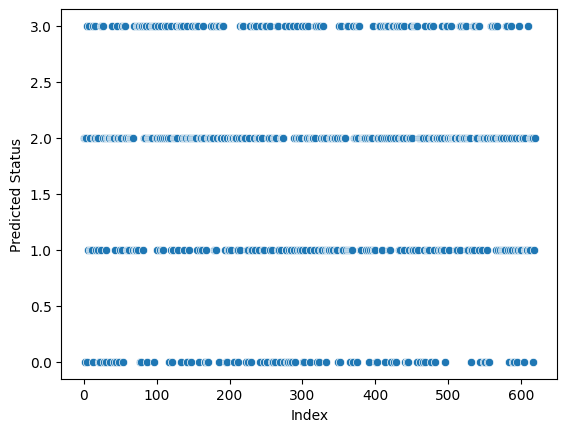

accuracy score: 0.6338709677419355
recall score: 0.6338709677419355
classification report:               precision    recall  f1-score   support

           0       0.17      0.65      0.27        23
           1       0.83      0.68      0.75       191
           2       0.94      0.61      0.74       370
           3       0.17      0.64      0.27        36

    accuracy                           0.63       620
   macro avg       0.53      0.64      0.51       620
weighted avg       0.83      0.63      0.70       620



In [191]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

sns.scatterplot(x=range(len(train_preds)), y=train_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_train, train_preds)}")
print(f"recall score: {recall_score(y_train, train_preds, average='weighted')}")
print(f"classification report: {classification_report(y_train, train_preds)}")

In [192]:
from imblearn.over_sampling import SMOTE

In [193]:
smote = SMOTE(random_state=46)

In [194]:
x_train_ss,y_train = smote.fit_resample(x_train_ss,y_train)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [195]:
logreg_model = LogisticRegression(class_weight='balanced',max_iter=1000)

In [196]:
logreg_model.fit(x_train_ss,y_train)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_s

LogisticRegression(class_weight='balanced', max_iter=1000)

In [197]:
train_preds = logreg_model.predict(x_train_ss)
test_preds = logreg_model.predict(x_test_ss)


/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/utils/extm

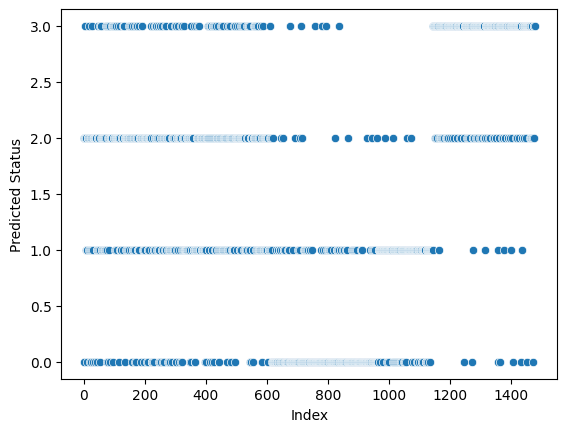

accuracy score: 0.7331081081081081
recall score: 0.7331081081081081
classification report:               precision    recall  f1-score   support

           0       0.76      0.76      0.76       370
           1       0.74      0.76      0.75       370
           2       0.70      0.70      0.70       370
           3       0.75      0.71      0.73       370

    accuracy                           0.73      1480
   macro avg       0.73      0.73      0.73      1480
weighted avg       0.73      0.73      0.73      1480



In [198]:

sns.scatterplot(x=range(len(train_preds)), y=train_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_train, train_preds)}")
print(f"recall score: {recall_score(y_train, train_preds, average='weighted')}")
print(f"classification report: {classification_report(y_train, train_preds)}")

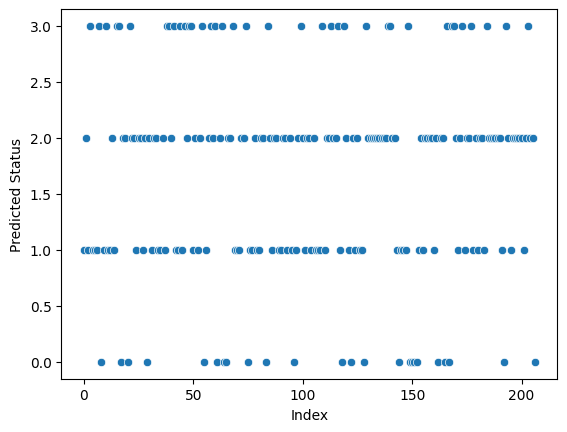

accuracy score: 0.6328502415458938
recall score: 0.6328502415458938
classification report:               precision    recall  f1-score   support

           0       0.17      0.50      0.25         8
           1       0.82      0.73      0.77        67
           2       0.90      0.63      0.74       123
           3       0.03      0.11      0.04         9

    accuracy                           0.63       207
   macro avg       0.48      0.49      0.45       207
weighted avg       0.80      0.63      0.70       207



In [199]:

sns.scatterplot(x=range(len(test_preds)), y=test_preds)
plt.xlabel("Index")
plt.ylabel("Predicted Status")
plt.show()

print(f"accuracy score: {accuracy_score(y_test, test_preds)}")
print(f"recall score: {recall_score(y_test, test_preds, average='weighted')}")
print(f"classification report: {classification_report(y_test, test_preds)}")

In [200]:
## logistic regression model is doing better than the cluster model but still not good enough. I will try to do some feature engineering and then i will try to build a random forest model.

In [201]:
pd.DataFrame(logreg_model.coef_, columns=x_train_ss.columns)

,loan_id,account_id,amount,duration,payments,frequency,disp_id,client_id,birth_number,district_id,total_trans,total_trans_amount,loan_intensity,amount_per_duration,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,-1.279874,0.576673,-0.309783,-1.457485,0.718387,0.178853,0.671172,0.464317,-0.130034,-0.193148,2.243405,-0.039951,-0.852711,0.718387,1.784749,0.444368,1.069369,0.922350,2.325424
1,0.601679,-0.189278,-0.554908,-2.017472,-0.083919,-0.078906,-0.258140,-0.216604,0.217935,-0.187777,2.143377,-0.024050,0.030030,-0.083919,-2.095728,-0.875995,-1.142803,-0.518207,-0.834338
2,0.763526,-0.376969,-0.255072,2.012069,-0.339790,0.000192,-0.354689,-0.189459,-0.036510,-0.145888,-2.404677,0.086903,0.363924,-0.339790,-2.126044,-1.002673,-1.618229,-1.775165,-2.002015
3,-0.085331,-0.010425,1.119763,1.462888,-0.294678,-0.100139,-0.058344,-0.058254,-0.051391,0.526812,-1.982105,-0.022902,0.458757,-0.294678,2.437023,1.434301,1.691663,1.371022,0.510929


“Customers with high transaction activity are more likely to belong to this class, while longer loan duration decreases the likelihood.”

In [202]:
from sklearn.ensemble import RandomForestClassifier

In [203]:
x_train_ss,y_train = smote.fit_resample(x_train_ss,y_train)

/Users/utkuseyithanoglu/Desktop/1999 czech banking/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [204]:
rf_model = RandomForestClassifier(random_state=46,class_weight='balanced')
rf_model.fit(x_train_ss,y_train)

RandomForestClassifier(class_weight='balanced', random_state=46)

In [205]:
train_preds_rf = rf_model.predict(x_train_ss)
test_preds_rf = rf_model.predict(x_test_ss)

In [206]:
print(f"accuracy score: {accuracy_score(y_test, test_preds_rf)}")
print(f"recall score: {recall_score(y_test, test_preds_rf, average='weighted')}")
print(f"classification report: {classification_report(y_test, test_preds_rf)}")

accuracy score: 0.8164251207729468
recall score: 0.8164251207729468
classification report:               precision    recall  f1-score   support

           0       0.25      0.25      0.25         8
           1       0.84      0.91      0.87        67
           2       0.91      0.85      0.88       123
           3       0.09      0.11      0.10         9

    accuracy                           0.82       207
   macro avg       0.52      0.53      0.53       207
weighted avg       0.83      0.82      0.82       207



In [207]:
y_train.value_counts()

status
2    370
3    370
1    370
0    370
Name: count, dtype: int64

In [208]:
np.round(pd.DataFrame(rf_model.feature_importances_,rf_model.feature_names_in_)*100,2).sort_values(by=0,ascending=False)

,0
total_trans,12.23
duration,12.06
loan_intensity,10.88
total_trans_amount,7.47
amount,7.34
payments,6.67
birth_number,6.55
amount_per_duration,6.03
district_id,5.90
disp_id,4.72


In [209]:
hyperparameters_dict = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]}

In [210]:
from sklearn.model_selection import GridSearchCV

In [211]:
GridSearchCVm=GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=hyperparameters_dict,
    scoring="f1_macro",
    verbose=3
)

In [212]:
GridSearchCVm.fit(x_train_ss,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.908 total time=   0.3s
[CV 2/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.942 total time=   0.3s
[CV 3/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.910 total time=   0.3s
[CV 4/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.939 total time=   0.3s
[CV 5/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.928 total time=   0.3s
[CV 1/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400;, score=0.904 total time=   0.6s
[CV 2/5] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=4

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 400]},
             scoring='f1_macro', verbose=3)

In [213]:
train_preds_grid = GridSearchCVm.predict(x_train_ss)
test_preds_grid = GridSearchCVm.predict(x_test_ss)

In [214]:
print(f"accuracy score: {accuracy_score(y_test, test_preds_grid)}")
print(f"recall score: {recall_score(y_test, test_preds_grid, average='weighted')}")
print(f"\nclassification report: \n{classification_report(y_test, test_preds_grid)}")

accuracy score: 0.8067632850241546
recall score: 0.8067632850241546

classification report: 
              precision    recall  f1-score   support

           0       0.25      0.25      0.25         8
           1       0.81      0.91      0.86        67
           2       0.90      0.84      0.87       123
           3       0.10      0.11      0.11         9

    accuracy                           0.81       207
   macro avg       0.52      0.53      0.52       207
weighted avg       0.81      0.81      0.81       207



In [215]:
from xgboost import XGBClassifier

In [216]:
xgb_model = XGBClassifier()

In [217]:
xgb_model.fit(x_train_ss,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [218]:
hyperparameter_dict = {
    'n_estimators' : [50,100,200],
    'learning_rate' : [0.2,0.3,0.4],
    'booster' : ['gblinear']
}


In [219]:
xgb_gridsearch_model = GridSearchCV(
    estimator =XGBClassifier(),
    param_grid = hyperparameter_dict,
    scoring = 'f1_macro'
)

In [220]:
xgb_gridsearch_model.fit(x_train_ss,y_train)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_b...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'booster': ['gblinear'],
                         'learning_rate': [0.2, 0.3, 0.4],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro')

In [221]:
train_preds_xgb = xgb_gridsearch_model.predict(x_train_ss)
test_preds_xgb = xgb_gridsearch_model.predict(x_test_ss)

In [222]:
print(f"accuracy score: {accuracy_score(y_test, test_preds_xgb)}")
print(f"recall score: {recall_score(y_test, test_preds_xgb, average='micro')}")
print(f"\nclassification report: \n{classification_report(y_test, test_preds_xgb)}")

accuracy score: 0.6328502415458938
recall score: 0.6328502415458938

classification report: 
              precision    recall  f1-score   support

           0       0.15      0.50      0.23         8
           1       0.80      0.73      0.77        67
           2       0.95      0.60      0.74       123
           3       0.10      0.44      0.16         9

    accuracy                           0.63       207
   macro avg       0.50      0.57      0.47       207
weighted avg       0.83      0.63      0.70       207



In [223]:
'''
import pickle
bundle = {
    "cluster_model": cluster_model,
    "model": GridSearchCVm.best_estimator_,   # final model
    "raw_feature_columns": x_train.columns.tolist(),
    "final_feature_columns": x_train_ss.columns.tolist()
}

with open("final_model_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)'''

'\nimport pickle\nbundle = {\n    "cluster_model": cluster_model,\n    "model": GridSearchCVm.best_estimator_,   # final model\n    "raw_feature_columns": x_train.columns.tolist(),\n    "final_feature_columns": x_train_ss.columns.tolist()\n}\n\nwith open("final_model_bundle.pkl", "wb") as f:\n    pickle.dump(bundle, f)'

In [227]:
main_df['target'] = main_df['status'].apply(lambda x: 1 if x in [0, 3] else 0)

In [ ]:
copy_df['status'].value_counts()

status
2    493
1    258
3     45
0     31
Name: count, dtype: int64

In [228]:
main_df['target'].value_counts()

target
0    751
1     76
Name: count, dtype: int64

In [229]:
main_df['payment_ratio'] = main_df['payments'] / main_df['amount']
main_df['amount_per_month'] = main_df['amount'] / main_df['duration']

In [278]:
main_df["trans_amount_per_trans"] = main_df["total_trans_amount"] / (main_df["total_trans"] + 1)

In [230]:
from sklearn.model_selection import train_test_split


In [279]:

x= main_df[[
    "amount",
    "duration",
    "payments",
    "total_trans",
    "total_trans_amount",
    "payment_ratio",
    "amount_per_month",
    "trans_amount_per_trans"
]]
y = main_df['target']


In [280]:
print(x.columns)

Index(['amount', 'duration', 'payments', 'total_trans', 'total_trans_amount',
       'payment_ratio', 'amount_per_month', 'trans_amount_per_trans'],
      dtype='object')


In [281]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [282]:
model = RandomForestClassifier(class_weight='balanced',random_state=46)
model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=46)

In [309]:
y_prob = model.predict_proba(x_test)[:,1]

y_pred = (y_prob > 0.147).astype(int)

In [310]:
print(f"accuracy score: {accuracy_score(y_test, y_pred)}")
print(f"recall score: {recall_score(y_test, y_pred, average='micro')}")
print(f"\nclassification report: \n{classification_report(y_test, y_pred)}")

accuracy score: 0.7771084337349398
recall score: 0.7771084337349398

classification report: 
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       151
           1       0.19      0.47      0.27        15

    accuracy                           0.78       166
   macro avg       0.57      0.64      0.57       166
weighted avg       0.87      0.78      0.81       166



In [311]:
hyperparameter_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [312]:
gridsearch_model = GridSearchCV(
    estimator =RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid = hyperparameter_dict,
    scoring = 'f1_macro'
)

In [313]:
gridsearch_model.fit(x_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [5, 8, 12, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300, 500]},
             scoring='f1_macro')

In [332]:
y_prob = model.predict_proba(x_test)[:,1]

y_pred = (y_prob > 0.149).astype(int)

In [333]:
print(f"accuracy score: {accuracy_score(y_test, y_pred)}")
print(f"recall score: {recall_score(y_test, y_pred, average='micro')}")
print(f"\nclassification report: \n{classification_report(y_test, y_pred)}")

accuracy score: 0.7771084337349398
recall score: 0.7771084337349398

classification report: 
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       151
           1       0.19      0.47      0.27        15

    accuracy                           0.78       166
   macro avg       0.57      0.64      0.57       166
weighted avg       0.87      0.78      0.81       166



In [335]:
import pickle

# 🔴 SENİN SEÇTİĞİN THRESHOLD
THRESHOLD = 0.149  # bunu değiştirebilirsin

# scaler kullandıysan ekle, yoksa None bırak
try:
    scaler
except NameError:
    scaler = None

bundle = {
    "model": model,
    "features": x_train.columns.tolist(),
    "threshold": THRESHOLD,
    "scaler": scaler
}

with open("loan_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Model başarıyla kaydedildi 🚀")

Model başarıyla kaydedildi 🚀
